<a href="https://colab.research.google.com/github/Pramod-kumar-dev/World-Happiness-Report-Exploration/blob/main/World_happiness_Report_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



World happiness Report Exploration



In [1]:
#Requried libaray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Download the multi-year CSV files from kaggle and load it using pandas
from google.colab import files
uploaded = files.upload()

Saving world_happiness_2015.csv to world_happiness_2015.csv
Saving world_happiness_2016.csv to world_happiness_2016.csv
Saving world_happiness_2017.csv to world_happiness_2017.csv
Saving world_happiness_2018.csv to world_happiness_2018.csv
Saving world_happiness_2019.csv to world_happiness_2019.csv
Saving world_happiness_2020.csv to world_happiness_2020.csv
Saving world_happiness_2021.csv to world_happiness_2021.csv
Saving world_happiness_2022.csv to world_happiness_2022.csv
Saving world_happiness_2023.csv to world_happiness_2023.csv
Saving world_happiness_2024.csv to world_happiness_2024.csv


In [5]:
# Standardize column across files and concatenate them into one DataFrame
df_2015 = pd.read_csv("world_happiness_2015.csv", sep=';')
df_2016 = pd.read_csv("world_happiness_2016.csv", sep=';')
df_2017 = pd.read_csv("world_happiness_2017.csv", sep=';')
df_2018 = pd.read_csv("world_happiness_2018.csv", sep=';')
df_2019 = pd.read_csv("world_happiness_2019.csv", sep=';')
df_2020 = pd.read_csv("world_happiness_2020.csv", sep=';')
df_2021= pd.read_csv("world_happiness_2021.csv", sep=';')
df_2022= pd.read_csv("world_happiness_2022.csv", sep=';')
df_2023 = pd.read_csv("world_happiness_2024.csv", sep=';')
df_2024 = pd.read_csv("world_happiness_2023.csv", sep=';')

print(df_2015.columns)
print(df_2016.columns)
print(df_2017.columns)
print(df_2018.columns)
print(df_2019.columns)
print(df_2020.columns)
print(df_2021.columns)
print(df_2022.columns)
print(df_2023.columns)
print(df_2024.columns)

Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')
Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')
Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')
Index(['Ranking', 'Country', 'Regional indicator', 'Happiness score',
       'GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='o

In [6]:
# Use numpy to calculate yearly mean happiness scores and identify the top 10 happiest countries

# Standardize column names and add a 'Year' column to each DataFrame
def prepare_df(df, year):
    df_copy = df.copy()
    df_copy['Year'] = year
    # Rename 'Ladder score' to 'Happiness score' for consistency
    if 'Ladder score' in df_copy.columns:
        df_copy.rename(columns={'Ladder score': 'Happiness score'}, inplace=True)
    return df_copy # Return the full dataframe, not just a subset

# List of all relevant columns for the combined dataframe
all_relevant_cols = [
    'Country', 'Happiness score', 'Year', 'Regional indicator',
    'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption',
    'Ranking' # Add Ranking back, it's useful
]

# Apply prepare_df to each DataFrame
dfs_prepared = [
    prepare_df(df_2015, 2015),
    prepare_df(df_2016, 2016),
    prepare_df(df_2017, 2017),
    prepare_df(df_2018, 2018),
    prepare_df(df_2019, 2019),
    prepare_df(df_2020, 2020),
    prepare_df(df_2021, 2021),
    prepare_df(df_2022, 2022),
    prepare_df(df_2023, 2023),
    prepare_df(df_2024, 2024)
]

# Concatenate all DataFrames, selecting only the relevant columns that exist in each DF
# This handles cases where some early years might not have all columns yet
final_dfs = []
for df_p in dfs_prepared:
    cols_to_include = [col for col in all_relevant_cols if col in df_p.columns]
    final_dfs.append(df_p[cols_to_include])

all_happiness_df = pd.concat(final_dfs, ignore_index=True)


# Convert numeric columns from object (due to commas) to float
numeric_cols_to_convert = [
    'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
]

for col in numeric_cols_to_convert:
    if col in all_happiness_df.columns:
        # Use errors='coerce' to turn unparseable values into NaN
        all_happiness_df[col] = all_happiness_df[col].astype(str).str.replace(',', '.').astype(float)

# Calculate yearly mean happiness scores
yearly_mean_happiness = all_happiness_df.groupby('Year')['Happiness score'].mean().reset_index()
print("\nYearly Mean Happiness Scores:")
print(yearly_mean_happiness)

# Identify the top 10 happiest countries based on average score across all available years
top_10_countries = all_happiness_df.groupby('Country')['Happiness score'].mean().nlargest(10).reset_index()
print("\nTop 10 Happiest Countries (Average across all years):")
print(top_10_countries)


Yearly Mean Happiness Scores:
   Year  Happiness score
0  2015         5.376139
1  2016         5.382185
2  2017         5.354019
3  2018         5.372920
4  2019         5.405077
5  2020         5.472830
6  2021         5.532814
7  2022         5.554175
8  2023         5.530882
9  2024         5.539755

Top 10 Happiest Countries (Average across all years):
       Country  Happiness score
0      Finland          7.67097
1      Denmark          7.58038
2      Iceland          7.52244
3       Norway          7.45654
4  Switzerland          7.45038
5  Netherlands          7.40751
6       Sweden          7.34326
7       Israel          7.25522
8  New Zealand          7.24974
9    Australia          7.20970


In [7]:
# Handle missing values appropriately and document your strategy


print("=== MISSING VALUES BEFORE HANDLING ===")
print(all_happiness_df.isnull().sum())

# 1. Structural Columns: 'Country' and 'Year'

all_happiness_df.dropna(subset=['Country', 'Year'], inplace=True)

# 2. Target Variable: 'Happiness score'

all_happiness_df.dropna(subset=['Happiness score'], inplace=True)

# 3. Numeric Contributing Factors (GDP, Social Support, Life Expectancy, Freedom, etc.)

contributing_factors = [
    'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
]


for col in contributing_factors:
    if col in all_happiness_df.columns:
        if all_happiness_df[col].dtype == 'object':
            all_happiness_df[col] = all_happiness_df[col].astype(str).str.replace(',', '.').astype(float)


for col in contributing_factors:
    if col in all_happiness_df.columns:
        all_happiness_df[col] = all_happiness_df.groupby('Country')[col].transform(lambda x: x.fillna(x.mean()))


for col in contributing_factors:
    if col in all_happiness_df.columns:
        all_happiness_df[col] = all_happiness_df.groupby('Year')[col].transform(lambda x: x.fillna(x.median()))

# 4. Categorical Columns: 'Regional indicator'

if 'Regional indicator' in all_happiness_df.columns:
    # Forward/backward fill regional mapping per country
    all_happiness_df['Regional indicator'] = all_happiness_df.groupby('Country')['Regional indicator'].ffill().bfill()
    all_happiness_df['Regional indicator'] = all_happiness_df['Regional indicator'].fillna('Unknown')

print("\n=== MISSING VALUES AFTER HANDLING ===")
print(all_happiness_df.isnull().sum())

=== MISSING VALUES BEFORE HANDLING ===
Country                         0
Happiness score                 0
Year                            0
Regional indicator              3
GDP per capita                  0
Social support                  0
Healthy life expectancy         1
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Ranking                         0
dtype: int64

=== MISSING VALUES AFTER HANDLING ===
Country                         0
Happiness score                 0
Year                            0
Regional indicator              0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Ranking                         0
dtype: int64


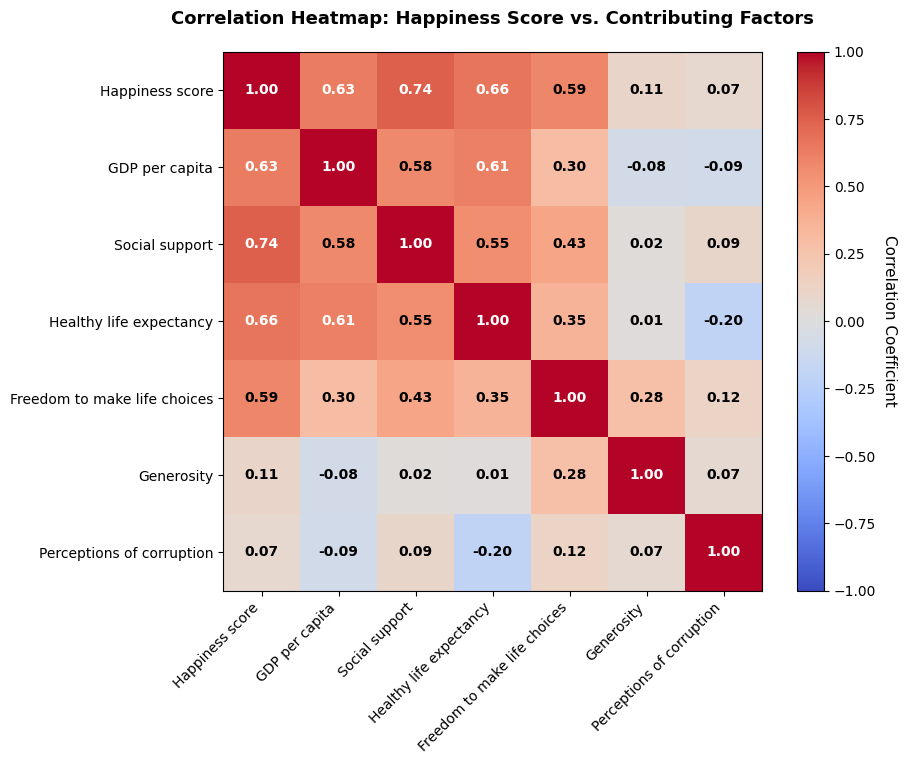

In [8]:
#Create a correlation heatmap(using imshow) between happiness score and cotributing factors


# 1. Re-aggregate the datasets to include both Happiness Score and all contributing factors
dfs = [df_2015, df_2016, df_2017, df_2018, df_2019, df_2020, df_2021, df_2022, df_2023, df_2024]
years = list(range(2015, 2025))

heatmap_cols = [
    'Happiness score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption'
]

all_features_list = []
for df, year in zip(dfs, years):
    df_copy = df.copy()

    if 'Ladder score' in df_copy.columns:
        df_copy.rename(columns={'Ladder score': 'Happiness score'}, inplace=True)


    available_cols = [col for col in heatmap_cols if col in df_copy.columns]
    all_features_list.append(df_copy[available_cols])

df_heatmap = pd.concat(all_features_list, ignore_index=True)

# 2. Clean numeric formats (convert objects/strings with commas to float)
for col in heatmap_cols:
    if col in df_heatmap.columns:
        if df_heatmap[col].dtype == 'object':
            df_heatmap[col] = df_heatmap[col].astype(str).str.replace(',', '.').astype(float)

df_heatmap = df_heatmap.fillna(df_heatmap.median(numeric_only=True))

# 3. Calculate the correlation matrix
corr_matrix = df_heatmap[heatmap_cols].corr()

# 4. Plot the heatmap using plt.imshow()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar indicator
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=-90, va="bottom", fontsize=11)

# Set ticks and clean labels to prevent overlapping
ax.set_xticks(range(len(heatmap_cols)))
ax.set_yticks(range(len(heatmap_cols)))
ax.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(heatmap_cols, fontsize=10)

# Loop over the matrix data dimensions to overlay text annotations inside the boxes
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        val = corr_matrix.iloc[i, j]
        # Choose text color (white or black) dynamically based on background intensity for readability
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontweight='bold')

ax.set_title('Correlation Heatmap: Happiness Score vs. Contributing Factors', fontsize=13, pad=20, fontweight='bold')

# Save the final high-quality figure directly to your environment workspace
plt.savefig('happiness_correlation_heatmap.png', dpi=300, bbox_inches='tight')

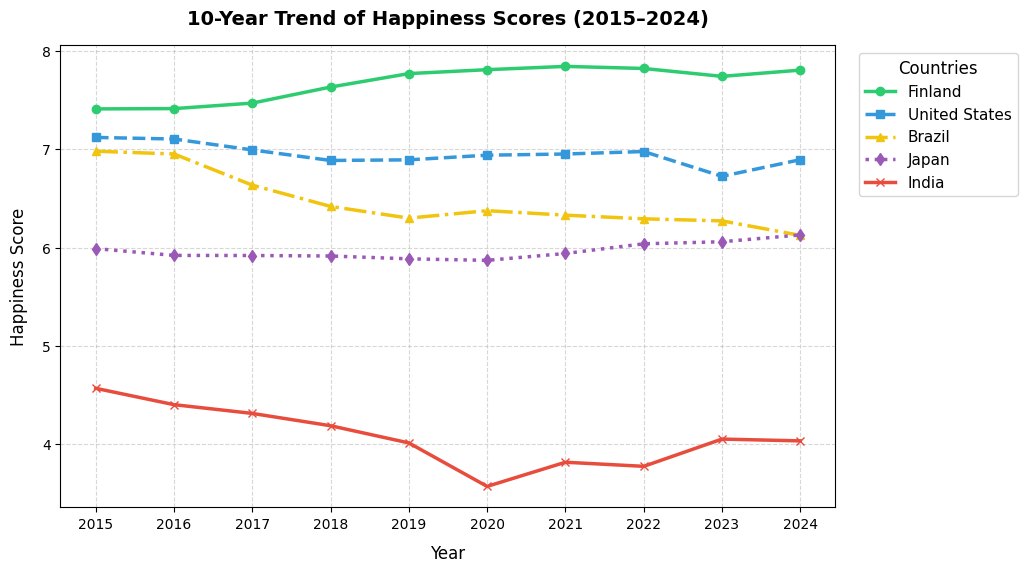

In [9]:
#Plot the trend of happiness scores over years for 5 selected countries on a single line chart


# 1. Select 5 distinct countries to show a diverse range of global trends
selected_countries = ['Finland', 'United States', 'Brazil', 'Japan', 'India']

# 2. Filter and prepare the data
df_trends = all_happiness_df[all_happiness_df['Country'].isin(selected_countries)].copy()

# Ensure the timeline is perfectly sequential for accurate line rendering
df_trends = df_trends.sort_values(by=['Country', 'Year'])

# 3. Initialize the plot using subplots (avoiding plt.figure() as per guidelines)
fig, ax = plt.subplots(figsize=(10, 6))

styles = {
    'Finland': {'color': '#2ecc71', 'marker': 'o', 'linestyle': '-'},        # Rising/Top Tier
    'United States': {'color': '#3498db', 'marker': 's', 'linestyle': '--'},   # High Stable Tier
    'Brazil': {'color': '#f1c40f', 'marker': '^', 'linestyle': '-.'},   # Fluctuating Tier
    'Japan': {'color': '#9b59b6', 'marker': 'd', 'linestyle': ':'},    # Mid Tier
    'India': {'color': '#e74c3c', 'marker': 'x', 'linestyle': '-'}     # Lower/Developing Tier
}

# 4. Plot each country's line graph
for country in selected_countries:
    country_data = df_trends[df_trends['Country'] == country]
    if not country_data.empty:
        ax.plot(
            country_data['Year'],
            country_data['Happiness score'],
            label=country,
            color=styles[country]['color'],
            marker=styles[country]['marker'],
            linestyle=styles[country]['linestyle'],
            linewidth=2.5,
            markersize=6
        )

ax.set_title('10-Year Trend of Happiness Scores (2015–2024)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12, labelpad=10)
ax.set_ylabel('Happiness Score', fontsize=12, labelpad=10)

ax.set_xticks(range(2015, 2025))
ax.set_xticklabels(range(2015, 2025), fontsize=10)
ax.tick_params(axis='y', labelsize=10)

ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(title='Countries', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11, title_fontsize=12)

plt.savefig('happiness_trends_5_countries.png', dpi=300, bbox_inches='tight')

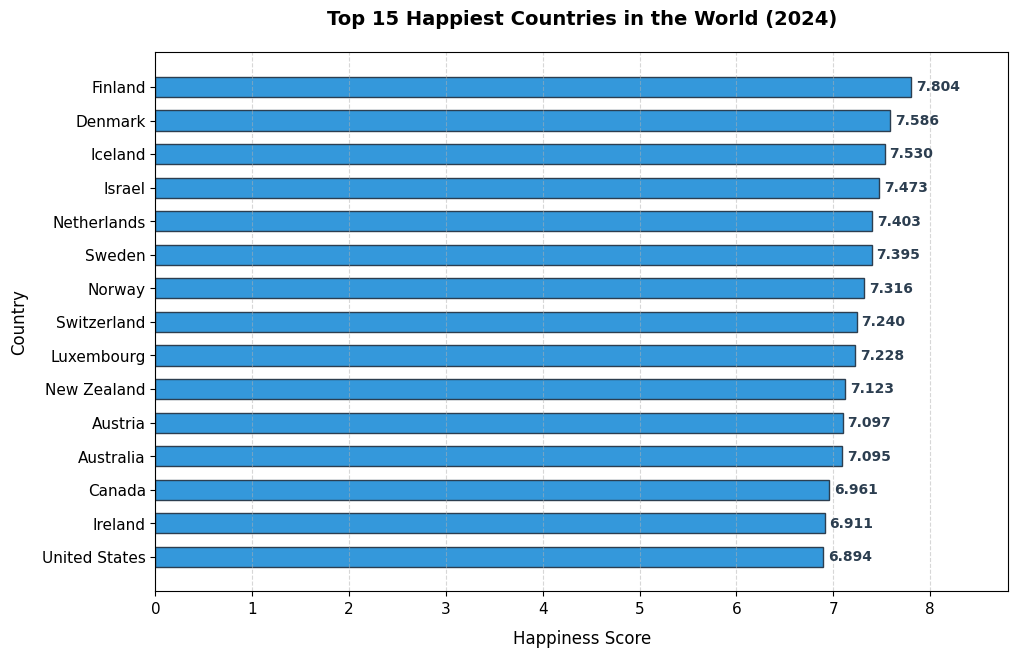

In [10]:
#Create horizontal bar chart of the top 15 happiest countries in the most recent years

latest_year = all_happiness_df['Year'].max()

df_latest = all_happiness_df[all_happiness_df['Year'] == latest_year].copy()


if df_latest['Happiness score'].dtype == 'object':
    df_latest['Happiness score'] = df_latest['Happiness score'].astype(str).str.replace(',', '.').astype(float)

df_top15 = df_latest.nlargest(15, 'Happiness score')


df_top15 = df_top15.sort_values(by='Happiness score', ascending=True)


fig, ax = plt.subplots(figsize=(11, 7))


bars = ax.barh(df_top15['Country'], df_top15['Happiness score'], color='#3498db', edgecolor='#2c3e50', height=0.6)

for bar in bars:
    score_val = bar.get_width()
    ax.text(
        score_val + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{score_val:.3f}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

ax.set_title(f'Top 15 Happiest Countries in the World ({latest_year})', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Happiness Score', fontsize=12, labelpad=10)
ax.set_ylabel('Country', fontsize=12, labelpad=10)

ax.set_xlim(0, max(df_top15['Happiness score']) + 1)
ax.tick_params(axis='both', labelsize=11)

ax.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.savefig('top_15_happiest_countries.png', dpi=300, bbox_inches='tight')

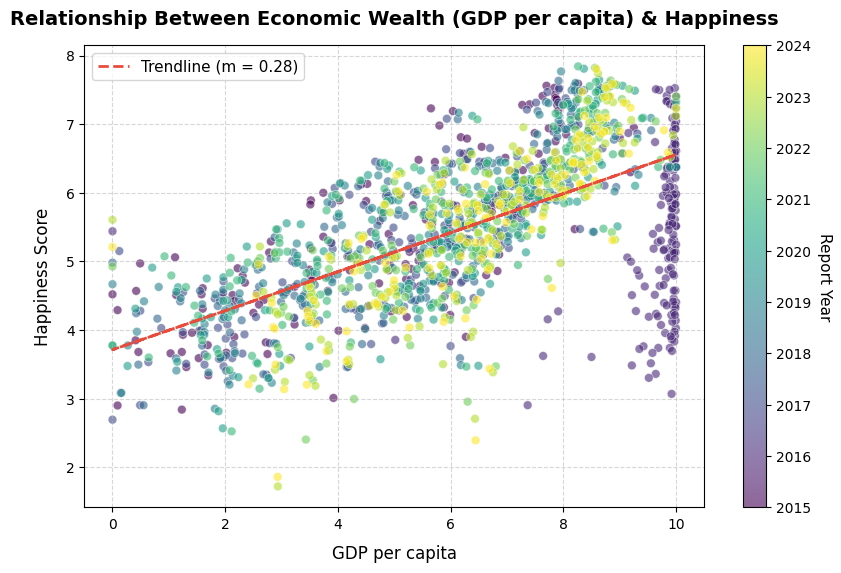

In [11]:
# use a scatter plot to visualize the relationship between GDP per capita and happiness



df_scatter = all_happiness_df[['GDP per capita', 'Happiness score', 'Year']].copy()

for col in ['GDP per capita', 'Happiness score']:
    if df_scatter[col].dtype == 'object':
        df_scatter[col] = df_scatter[col].astype(str).str.replace(',', '.').astype(float)

df_scatter.dropna(subset=['GDP per capita', 'Happiness score'], inplace=True)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_scatter['GDP per capita'],
    df_scatter['Happiness score'],
    c=df_scatter['Year'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5,
    s=40
)


x = df_scatter['GDP per capita']
y = df_scatter['Happiness score']
m, b = np.polyfit(x, y, 1) # Linear regression fit (y = mx + b)
ax.plot(x, m*x + b, color='#e74c3c', linestyle='--', linewidth=2, label=f'Trendline (m = {m:.2f})')


ax.set_title('Relationship Between Economic Wealth (GDP per capita) & Happiness', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('GDP per capita', fontsize=12, labelpad=10)
ax.set_ylabel('Happiness Score', fontsize=12, labelpad=10)


cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Report Year', rotation=-90, va="bottom", fontsize=11)
cbar.set_ticks(range(int(df_scatter['Year'].min()), int(df_scatter['Year'].max()) + 1))


ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=11)

plt.savefig('gdp_vs_happiness_scatter.png', dpi=300, bbox_inches='tight')

In [12]:
# Save the merged and cleaned dataset as a new csv file

output_filename = 'merged_cleaned_world_happiness.csv'

all_happiness_df.to_csv(output_filename, sep=';', index=False)

print(f"Success! The merged and cleaned dataset has been saved as: '{output_filename}'")
print(f"Final shape of exported data: {all_happiness_df.shape}")

Success! The merged and cleaned dataset has been saved as: 'merged_cleaned_world_happiness.csv'
Final shape of exported data: (1502, 11)
